# 02 — DeMemte E5 (variante ganadora)

Reproducción end-to-end de la variante ganadora `e5_combined_dropout_ood_tau_150`:
backbone ResNet18 congelado + memoria VQ + atractor residual + gate adaptativo de 4 señales
(uncertainty, familiarity, conflict, ood_risk).

**Tres fases**:
- F1: pretrain del latente con masking (35% feature dropout)
- F2: atractor + gate + clasificadores con corrupciones aleatorias
- F3: fine-tune conjunto limpio+corrupto + anti-pareidolia loss

Con `RUN_TRAINING=False` (default) se carga el checkpoint legacy ganador tau=1.50.
El checkpoint preexistente de `experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42/`
se copia a `out/e5_best.pt` para reproducir la accuracy histórica `81.2 / 52.1`.

In [7]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [8]:
import json, shutil
from dataclasses import asdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import E5Config, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import make_dememte_e5
from dememte.training import train_dememte_critical
from dememte.evaluation import evaluate_dememte_suite, signal_curve_rows
from dememte.io import save_checkpoint, load_checkpoint, write_json, write_csv, ensure_dir

RUN_TRAINING = True
USE_LEGACY_WINNER = True

cfg = E5Config()
cfg.data_dir = resolve_data_dir(cfg)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '02_e5_winner' / 'out')
CKPT = OUT / 'e5_best.pt'
LEGACY_CKPT = ROOT / 'experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42/e5_combined_dropout_ood_tau_150/e5_combined_dropout_ood_tau_150_best.pt'
seed_everything(cfg.seed)
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "/home/nakato/projects/Dememte/experiments/data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "device": "cuda",
  "val_ratio": 0.2,
  "split_seed": 42,
  "benchmark_protocol": "historical_trainval_resplit",
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "lr_attractor": 0.0003,
  "lr_gate": 0.0001,
  "weight_decay": 0.0001,
  "epochs_phase1_max": 4,
  "epochs_phase2_max": 6,
  "epochs_phase3_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 128,
  "attractor_hidden": 512,
  "gate_hidden": 16,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "familiarity_midpoint": 0.0,
  "familiarity_width": 0.5,
  "ood_tau": 1.5,
  "ood_beta": 8.0,
  "denoise_weight": 0.5,
  "vq_weight": 0.25,
  "antipareidolia_weight": 0.1,
  "gate_entropy_reg": 0.01,
  "gate_raw_entropy_reg": 0.01,
  "weak_sigreg_weight": 0.01,
  "weak_sigreg_sketch_dim": 64,
  "gate

## Datos

In [9]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=cfg.data_dir,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    split_seed=cfg.split_seed,
    protocol=cfg.benchmark_protocol,
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Modelo E5

In [10]:
model = make_dememte_e5(cfg, device=device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'params total: {n_total:,} | trainable (post-init): {n_trainable:,}')

params total: 11,677,039 | trainable (post-init): 500,527


## Entrenamiento (opcional) o carga del checkpoint

In [11]:
if RUN_TRAINING:
    seed_everything(cfg.seed)
    model = make_dememte_e5(cfg, device=device)
    model, best_acc = train_dememte_critical(model, tr_loader, va_loader, cfg, device)
    save_checkpoint(model, CKPT, extra={'best_val': best_acc, 'config': asdict(cfg)})
    print(f'saved {CKPT} (best_val={best_acc:.4f})')
else:
    if USE_LEGACY_WINNER and LEGACY_CKPT.exists():
        print('using legacy E5 winner checkpoint:', LEGACY_CKPT)
        shutil.copy(LEGACY_CKPT, CKPT)
    elif not CKPT.exists() and LEGACY_CKPT.exists():
        print('seeding out/ with legacy E5 checkpoint:', LEGACY_CKPT)
        shutil.copy(LEGACY_CKPT, CKPT)
    payload = load_checkpoint(model, CKPT, device=device, strict=True)
    print('loaded:', CKPT, '| best_val:', payload.get('best_val'))

[P1 01] tr_loss=1.2240 val_loss=1.3068 val_recon=1.7175 val_vq=0.9813
[P1 02] tr_loss=1.2131 val_loss=1.3522 val_recon=1.7559 val_vq=1.1232
[P1 03] tr_loss=1.2192 val_loss=1.4340 val_recon=1.8107 val_vq=1.3313
[P1 04] tr_loss=1.2341 val_loss=1.4846 val_recon=1.9009 val_vq=1.3505
P1 early stop at epoch 4
logits: (4, 102) | gate: (4, 1, 1, 1) | prior: (4, 1, 1, 1) | raw: (4, 1, 1, 1) | sigreg: 17.544357299804688 | denoise: 0.03180927410721779 | vq: 0.8984712362289429
[P2 01] tr_loss=22.3781 val_loss=15.2273 val_gate=0.0696 val_raw=0.1128
[P2 02] tr_loss=13.2306 val_loss=11.2784 val_gate=0.0772 val_raw=0.1206
[P2 03] tr_loss=10.0025 val_loss=9.5440 val_gate=0.0827 val_raw=0.1305
[P2 04] tr_loss=7.9832 val_loss=8.0091 val_gate=0.0904 val_raw=0.1418
[P2 05] tr_loss=6.3270 val_loss=6.4955 val_gate=0.0965 val_raw=0.1537
[P2 06] tr_loss=5.2480 val_loss=5.9283 val_gate=0.1045 val_raw=0.1672
phase2 corrupt gate mean: 0.10473565012216568 | prior: 0.5038694143295288 | raw: 0.16303864121437073
[P3 

## Evaluación clean + corrupt + métricas del gate

In [12]:
metrics = evaluate_dememte_suite(model, te_loader, device=device, return_predictions=True)
clean_record = metrics.pop('clean_record')
corrupt_records = metrics.pop('corruption_records')

predictions = clean_record.pop('predictions', [])
for rows in corrupt_records.values():
    for rec in rows:
        predictions.extend(rec.pop('predictions', []))

summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float, bool))}
summary.update({'protocol': meta['protocol'], 'split_seed': meta['split_seed'], 'variant': 'e5_combined_dropout_ood_tau_150'})
write_json(summary, OUT / 'metrics.json')
write_csv(predictions, OUT / 'predictions.csv')
write_csv(signal_curve_rows('e5_combined_dropout_ood_tau_150', 'E5 winner', clean_record, corrupt_records), OUT / 'signal_curves.csv')
print(json.dumps(summary, indent=2))

{
  "clean_acc": 0.8118393234672304,
  "corrupt_acc_avg": 0.5212636201008295,
  "corrupt_acc_gaussian_noise": 0.33956740933485113,
  "corrupt_acc_pixel_mask": 0.3157152924594785,
  "corrupt_acc_cutout": 0.7043963788149835,
  "corrupt_acc_blur": 0.7253753997940046,
  "gate_mean_clean": 0.2347576916217804,
  "pred_change_rate": 0.9935084295549411,
  "beneficial_changes": 0.5172114706998429,
  "harmful_changes": 0.004607795305469725,
  "pareidolia_rate": 0.0003117038000758931,
  "gate_entropy": 0.441603422164917,
  "ece_clean": 0.3592402495020947,
  "ece_corrupt_avg": 0.261126493022191,
  "nll_clean": 1.2098204245723667,
  "nll_corrupt_avg": 2.2729752123811164,
  "brier_clean": 0.43386476690602066,
  "brier_corrupt_avg": 0.6995124887923598,
  "protocol": "historical_trainval_resplit",
  "split_seed": 42,
  "variant": "e5_combined_dropout_ood_tau_150"
}


## Curvas del gate por corrupción/severidad

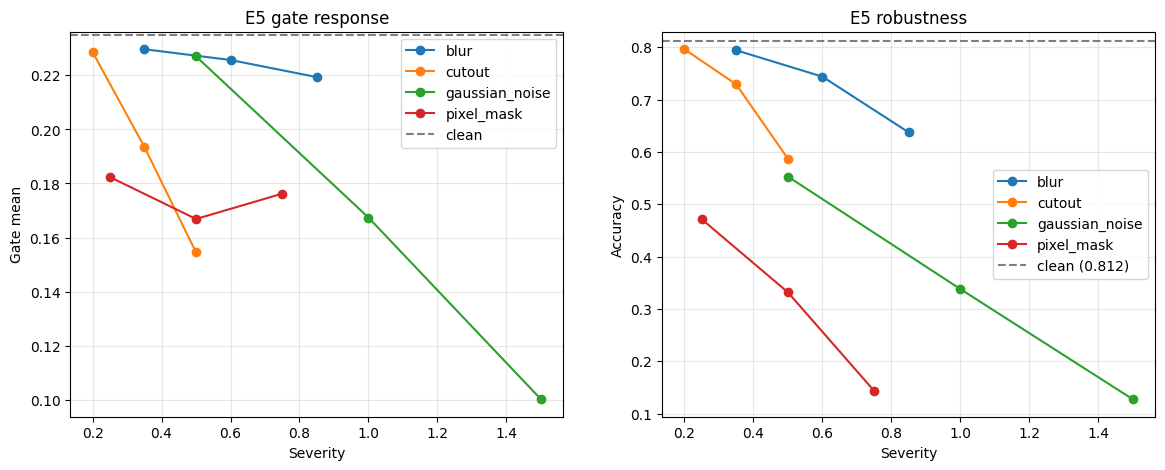

In [13]:
curves = pd.read_csv(OUT / 'signal_curves.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for corr, sub in curves[curves['corruption'] != 'clean'].groupby('corruption'):
    axes[0].plot(sub['severity'], sub['gate_mean'], marker='o', label=corr)
    axes[1].plot(sub['severity'], sub['acc'], marker='o', label=corr)
clean_row = curves[curves['corruption'] == 'clean'].iloc[0]
axes[0].axhline(clean_row['gate_mean'], linestyle='--', color='k', alpha=0.5, label='clean')
axes[1].axhline(clean_row['acc'], linestyle='--', color='k', alpha=0.5, label=f"clean ({clean_row['acc']:.3f})")
axes[0].set_xlabel('Severity'); axes[0].set_ylabel('Gate mean'); axes[0].set_title('E5 gate response')
axes[1].set_xlabel('Severity'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('E5 robustness')
for ax in axes: ax.grid(alpha=0.3); ax.legend()
ensure_dir(OUT / 'gate_plots')
fig.savefig(OUT / 'gate_plots' / 'gate_and_robustness.png', dpi=120, bbox_inches='tight')
plt.show()